# EDA + ETL + Consultas SQL con Pandas
## Análisis de Datos Proyecto: Análisis Estratégico de Ciberseguridad Global: Tendencias, Impacto Financiero y Defensa (2015-2024)




### 📋 Objetivos del Notebook

1. *Cargar datos* desde la base de datos SQLite a Pandas DataFrames
2. **Explorar los datos** (`EDA`) - entender estructura y calidad
3. _**Transformar los datos**_ (`ETL`) - limpiar y preparar
4. **Ejecutar consultas SQL** - practicar las 9 consultas del taller
5. **Visualizar resultados** - gráficos para mejor comprensión

---

In [1]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')
%pwd
%cd "/content/drive/MyDrive/bootcamp/Proyecto"
%pwd

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/bootcamp/Proyecto


'/content/drive/MyDrive/bootcamp/Proyecto'

## 📚 PASO 1: Importar Librerías Necesarias

Importamos las librerías que vamos a usar para trabajar con datos.

In [2]:
# ============================================
# IMPORTAR LIBRERÍAS
# ============================================

# Pandas para manejar datos tabulares (DataFrames)
import pandas as pd


# SQLite para conectar a la base de datos
import sqlite3


# Matplotlib y Seaborn para gráficos
import matplotlib.pyplot as plt
import seaborn as sns


# NumPy para operaciones numéricas
import numpy as np

# Matplotlib y Seaborn para gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración para ver todas las columnas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Mensaje de confirmación
print("✅ Librerías importadas correctamente")


✅ Librerías importadas correctamente


## 📚 PASO 2: Conectar a la Base de Datos

Nos conectamos a la base de datos SQLite para poder leer los datos.

In [3]:
# ============================================
# CONEXIÓN A LA BASE DE DATOS
# ============================================

# Nombre del archivo de la base de datos
db_name = "ciberseguridad.db"

# Conectar a la base de datos
conn = sqlite3.connect(db_name)

# Asegurar que las tablas existan ejecutando el script SQL
try:
  with open("ciberseguridad.sql", "r") as f:
    sql_script = f.read()
    conn.executescript(sql_script)
    print("✅ Tablas creadas correctamente")
except Exception as e:
  print(f"⚠️ Error al ejecutar el Script SQL: {e}")

# --------------------------------------------------------

# Verificar conexión
print(f"✅ Conexión a la base de datos establecida a: {db_name}")


⚠️ Error al ejecutar el Script SQL: table "amenazas" already exists
✅ Conexión a la base de datos establecida a: ciberseguridad.db


## 📚 PASO 3: Ver Tablas Disponibles

Vamos a ver qué tablas tiene nuestra base de datos.

In [4]:
# ============================================
# VER TABLAS DISPONIBLES
# ============================================

# Consulta para ver todas las tablas
query_tablas = "SELECT name FROM sqlite_master WHERE type='table';"


# Ejecutar consulta y cargar en DataFrame
df_tablas = pd.read_sql_query(query_tablas, conn)


# Mostrar tablas
print("✅ Tablas disponibles:")
df_tablas




✅ Tablas disponibles:


,name
0,amenazas


## 📚 PASO 4: Cargar Datos a DataFrames (ETL - Extract)

Cargamos cada tabla importante a un DataFrame de pandas para trabajar con ellas.

In [5]:
# ============================================
# CARGAR DATOS A DATAFRAMES
# ============================================

# Cargar tabla de incidentes reportados
df_amenazas = pd.read_sql_query("SELECT * FROM amenazas LIMIT 100", conn)


# Cargar tabla de categorías de amenazas (Ransomware, Phishing, etc.)
df_tipos_ataque = pd.read_sql_query("SELECT attack_type FROM amenazas LIMIT 100", conn)


# Cargar tabla de costos de respuesta y mitigación
df_industria = pd.read_sql_query("SELECT target_industry FROM amenazas LIMIT 100", conn)


# Cargar tabla de activos afectados (Servidores, Base de Datos, Endpoints)
df_year = pd.read_sql_query("SELECT year FROM amenazas LIMIT 100", conn)


# Mensaje de confirmación
print("✅ Datos de Ciberseguridad cargados correctamente a DataFrames")
df_amenazas.info()

✅ Datos de Ciberseguridad cargados correctamente a DataFrames
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   country                            100 non-null    object 
 1   year                               100 non-null    int64  
 2   attack_type                        100 non-null    object 
 3   target_industry                    100 non-null    object 
 4   financial_loss_in_million_         100 non-null    float64
 5   number_of_affected_users           100 non-null    int64  
 6   attack_source                      100 non-null    object 
 7   security_vulnerability_type        100 non-null    object 
 8   defense_mechanism_used             100 non-null    object 
 9   incident_resolution_time_in_hours  100 non-null    int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 7.9+ KB


## 📊 PASO 5: EDA - Exploración Inicial de Datos

Vamos a explorar los datos para entender su estructura y calidad.

### 5.1 Ver Primeras Filas de Cada Tabla

In [6]:
# ============================================
# VER PRIMERAS FILAS AMENAZAS
# ============================================
df_amenazas.head()


,country,year,attack_type,target_industry,financial_loss_in_million_,number_of_affected_users,attack_source,security_vulnerability_type,defense_mechanism_used,incident_resolution_time_in_hours
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


### 5.2 Ver Información de las Tablas

In [7]:
# ============================================
# INFORMACIÓN DE LAS TABLAS AMENAZAS
# ============================================
df_amenazas.info()





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   country                            100 non-null    object 
 1   year                               100 non-null    int64  
 2   attack_type                        100 non-null    object 
 3   target_industry                    100 non-null    object 
 4   financial_loss_in_million_         100 non-null    float64
 5   number_of_affected_users           100 non-null    int64  
 6   attack_source                      100 non-null    object 
 7   security_vulnerability_type        100 non-null    object 
 8   defense_mechanism_used             100 non-null    object 
 9   incident_resolution_time_in_hours  100 non-null    int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 7.9+ KB


In [8]:
# Mostrar los ultimos 5
df_amenazas.tail()

,country,year,attack_type,target_industry,financial_loss_in_million_,number_of_affected_users,attack_source,security_vulnerability_type,defense_mechanism_used,incident_resolution_time_in_hours
95,UK,2020,Ransomware,Banking,49.23,128594,Nation-state,Weak Passwords,Firewall,53
96,Germany,2024,Phishing,Healthcare,84.53,189430,Nation-state,Social Engineering,Firewall,1
97,France,2021,DDoS,Healthcare,90.63,603327,Nation-state,Unpatched Software,AI-based Detection,15
98,UK,2021,DDoS,Education,80.26,276593,Nation-state,Social Engineering,Encryption,36
99,Japan,2023,Malware,Education,22.87,975282,Insider,Unpatched Software,Firewall,49


In [9]:
# Mostrar el Orden
df_amenazas.shape

(100, 10)

### 5.3 Verificar Valores Faltantes

In [10]:
# ============================================
# VERIFICAR VALORES FALTANTES
# ============================================

print("🔍 VALORES FALTANTES - PROYECTOS")
print(df_amenazas.isnull().sum())

print("\n🔍 VALORES FALTANTES - TIPOS DE ENERGÍA")
print(df_amenazas.isnull().sum())



🔍 VALORES FALTANTES - PROYECTOS
country                              0
year                                 0
attack_type                          0
target_industry                      0
financial_loss_in_million_           0
number_of_affected_users             0
attack_source                        0
security_vulnerability_type          0
defense_mechanism_used               0
incident_resolution_time_in_hours    0
dtype: int64

🔍 VALORES FALTANTES - TIPOS DE ENERGÍA
country                              0
year                                 0
attack_type                          0
target_industry                      0
financial_loss_in_million_           0
number_of_affected_users             0
attack_source                        0
security_vulnerability_type          0
defense_mechanism_used               0
incident_resolution_time_in_hours    0
dtype: int64


### 5.4 Estadísticas Descriptivas

In [11]:
# ============================================
# ESTADÍSTICAS DESCRIPTIVAS PROYECTOS
# ============================================
df_amenazas.describe()




,year,financial_loss_in_million_,number_of_affected_users,incident_resolution_time_in_hours
count,100.00000,100.000000,100.000000,100.000000
mean,2019.56000,53.593400,526453.790000,39.380000
std,2.93471,27.795292,289187.761072,21.354525
min,2015.00000,1.510000,16585.000000,1.000000
25%,2017.00000,28.327500,271333.750000,23.750000
50%,2019.50000,55.110000,568465.500000,36.000000
75%,2022.00000,77.080000,774750.250000,61.000000
max,2024.00000,98.470000,996004.000000,71.000000


### PASO 5.5: Crear DataFrame Consolidado (Tipo Data Warehouse)

In [12]:
df_amenazas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   country                            100 non-null    object 
 1   year                               100 non-null    int64  
 2   attack_type                        100 non-null    object 
 3   target_industry                    100 non-null    object 
 4   financial_loss_in_million_         100 non-null    float64
 5   number_of_affected_users           100 non-null    int64  
 6   attack_source                      100 non-null    object 
 7   security_vulnerability_type        100 non-null    object 
 8   defense_mechanism_used             100 non-null    object 
 9   incident_resolution_time_in_hours  100 non-null    int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 7.9+ KB


In [14]:
# ============================================
# PASO 5.5: Crear DataFrame Consolidado (Tipo Data Warehouse)
# ============================================

print("🔄 Consolidando registros de ciberseguridad para el Data Warehouse...")

# Dado que df_tipos_ataque, df_industria y df_year provienen de la misma tabla
# y tienen el mismo límite (100), usamos el índice para asegurar una unión 1:1.

# 1. Unir df_amenazas con la columna de tipos de ataque
df_consolidado = pd.merge(df_amenazas,
                          df_tipos_ataque,
                          left_index=True,
                          right_index=True,
                          how='inner',
                          suffixes=('', '_dup1'))

# 2. Unir con la información de industria afectada
df_consolidado = pd.merge(df_consolidado,
                          df_industria,
                          left_index=True,
                          right_index=True,
                          how='inner',
                          suffixes=('', '_dup2'))

# 3. Unir con la información del año del incidente
df_consolidado = pd.merge(df_consolidado,
                          df_year,
                          left_index=True,
                          right_index=True,
                          how='inner',
                          suffixes=('', '_dup3'))

# ============================================
# LIMPIEZA Y RENOMBRADO (ESTRUCTURA DW)
# ============================================

# Eliminamos columnas duplicadas que pudieron crearse en el proceso de merge
df_consolidado = df_consolidado.loc[:, ~df_consolidado.columns.duplicated()]

# Renombrar para claridad en el reporte de seguridad
df_consolidado = df_consolidado.rename(columns={
    'attack_type': 'categoria_amenaza',
    'target_industry': 'sector_afectado',
    'year': 'periodo_anual',
    'impact': 'impacto_estimado',
    'severity': 'nivel_severidad'
})

print(f"✅ Data Warehouse local listo con {df_consolidado.shape[0]} registros consolidados.")
print(f"Columnas finales: {list(df_consolidado.columns)}")

# Mostrar una muestra del resultado
display(df_consolidado.head())


🔄 Consolidando registros de ciberseguridad para el Data Warehouse...
✅ Data Warehouse local listo con 100 registros consolidados.
Columnas finales: ['country', 'periodo_anual', 'categoria_amenaza', 'sector_afectado', 'financial_loss_in_million_', 'number_of_affected_users', 'attack_source', 'security_vulnerability_type', 'defense_mechanism_used', 'incident_resolution_time_in_hours', 'attack_type_dup1', 'target_industry_dup2', 'year_dup3']


,country,periodo_anual,categoria_amenaza,sector_afectado,financial_loss_in_million_,number_of_affected_users,attack_source,security_vulnerability_type,defense_mechanism_used,incident_resolution_time_in_hours,attack_type_dup1,target_industry_dup2,year_dup3
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63,Phishing,Education,2019
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71,Ransomware,Retail,2019
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20,Man-in-the-Middle,IT,2017
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7,Ransomware,Telecommunications,2024
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68,Man-in-the-Middle,IT,2018


In [15]:
print("📊 Primeras 5 filas del DataFrame consolidado:")
df_consolidado.head()


📊 Primeras 5 filas del DataFrame consolidado:


,country,periodo_anual,categoria_amenaza,sector_afectado,financial_loss_in_million_,number_of_affected_users,attack_source,security_vulnerability_type,defense_mechanism_used,incident_resolution_time_in_hours,attack_type_dup1,target_industry_dup2,year_dup3
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63,Phishing,Education,2019
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71,Ransomware,Retail,2019
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20,Man-in-the-Middle,IT,2017
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7,Ransomware,Telecommunications,2024
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68,Man-in-the-Middle,IT,2018


In [16]:
print("📊 Información del DataFrame consolidado:")
print(df_consolidado.info())

📊 Información del DataFrame consolidado:
<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   country                            100 non-null    object 
 1   periodo_anual                      100 non-null    int64  
 2   categoria_amenaza                  100 non-null    object 
 3   sector_afectado                    100 non-null    object 
 4   financial_loss_in_million_         100 non-null    float64
 5   number_of_affected_users           100 non-null    int64  
 6   attack_source                      100 non-null    object 
 7   security_vulnerability_type        100 non-null    object 
 8   defense_mechanism_used             100 non-null    object 
 9   incident_resolution_time_in_hours  100 non-null    int64  
 10  attack_type_dup1                   100 non-null    object 
 11  target_industry_dup2   

## 🔄 PASO 6: ETL - Transformación de Datos

### ETL Extracción Tranformación y Carga
### ELT Extracción Carga y Transformación
Ahora vamos a transformar y limpiar los datos si es necesario.

In [23]:
from IPython.core.interactiveshell import dis
# ============================================
# TRANSFORMACIÓN DE DATOS
# ============================================

# 1. Renombrar columnas para mayor claridad
df_incidentes_clean = df_amenazas.rename(columns={
    'year': 'periodo_anual',
    'attack_type': 'tipo_amenaza',
    'target_industry': 'sector_afectado',
    'financial_loss_in_million_': 'impacto_economico' # Corrected column name
})

# 2. Crear columna con el año (si existe fecha)
if "fecha_inicio" in df_incidentes_clean.columns:
    df_incidentes_clean["fecha_inicio"] = pd.to_datetime(df_incidentes_clean["fecha_inicio"])
    df_incidentes_clean["año_inicio"] = df_incidentes_clean["fecha_inicio"].dt.year


# 3. Calcular estadísticas de inversión por proyecto
columna_valor = 'impacto_economico'
df_impacto_resumen = df_incidentes_clean.groupby('tipo_amenaza').agg(
    total_perdida=(columna_valor, 'sum'),
    promedio_incidente=(columna_valor, 'mean'),
    frecuencia_ataques=(columna_valor, 'count')
).round(2)

# The previous renaming lines are no longer needed due to named aggregation

print("✅ Transformaciones de Ciberseguridad completadas:")
print(f"   - Columnas normalizadas a estándares de reporte de incidentes")
print(f"   - Análisis de impacto económico por categoría de ataque generado")
print(f"\n📊 Resumen de Impacto Financiero (Muestra de 100):")
display(df_impacto_resumen.head())

✅ Transformaciones de Ciberseguridad completadas:
   - Columnas normalizadas a estándares de reporte de incidentes
   - Análisis de impacto económico por categoría de ataque generado

📊 Resumen de Impacto Financiero (Muestra de 100):


,total_perdida,promedio_incidente,frecuencia_ataques
tipo_amenaza,,,
DDoS,1848.01,63.72,29
Malware,687.03,42.94,16
Man-in-the-Middle,628.86,48.37,13
Phishing,1182.41,53.75,22
Ransomware,406.16,40.62,10


## 🔍 PASO 7: EJECUTAR CONSULTAS SQL DEL TALLER

Ahora vamos a ejecutar las 9 consultas del taller usando pandas.

### Consulta 1: Todos los tipos de amenaza

In [24]:
# ============================================
# CONSULTA 1: Todos los tipos de amenaza
# ============================================

print("📋 CONSULTA 1: Todos los tipos de energía")


# Método 1: Usando el DataFrame ya cargado
consulta_1 = df_tipos_ataque

# Mostrar resultados
display(consulta_1)


print(f"\n✅ Total de tipos de energía: {len(consulta_1)}")

📋 CONSULTA 1: Todos los tipos de energía


,attack_type
0,Phishing
1,Ransomware
2,Man-in-the-Middle
3,Ransomware
4,Man-in-the-Middle
...,...
2995,Ransomware
2996,SQL Injection
2997,SQL Injection
2998,SQL Injection



✅ Total de tipos de energía: 3000


### CONSULTA 2: Proyectos con tipo de amenaza Phishing


In [28]:
# ============================================
# CONSULTA 2: Proyectos con tipo de amenaza Phishing
# ============================================

print("📋 CONSULTA 2: Nombre y ubicación de amenaza (tipo amenaza Phishing )")


# Filtrar proyectos donde attack_type = Phishing
consulta_2 = df_amenazas[df_amenazas['attack_type'] == 'Phishing'][['country', 'attack_type']]


# Mostrar resultados
display(consulta_2)


print(f"\n✅ Total de paises con tipo de amenaza Phishing : {len(consulta_2)}")

📋 CONSULTA 2: Nombre y ubicación de amenaza (tipo amenaza Phishing )


,country,attack_type
0,China,Phishing
10,China,Phishing
15,Australia,Phishing
23,Japan,Phishing
25,China,Phishing
33,Japan,Phishing
34,Brazil,Phishing
35,Brazil,Phishing
49,Japan,Phishing
52,UK,Phishing



✅ Total de paises con tipo de amenaza Phishing : 22


### Consulta 3: Todas los amenazas

In [29]:
# ============================================
# CONSULTA 3: Todos los proyectos
# ============================================

print("📋 CONSULTA 3: Todos las amenazas")


# Usar el DataFrame completo
consulta_3 = df_amenazas


# Mostrar resultados
display(consulta_3)



print(f"\n✅ Total de proyectos: {len(consulta_3)}")

📋 CONSULTA 3: Todos los proyectos


,country,year,attack_type,target_industry,financial_loss_in_million_,number_of_affected_users,attack_source,security_vulnerability_type,defense_mechanism_used,incident_resolution_time_in_hours
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68
...,...,...,...,...,...,...,...,...,...,...
95,UK,2020,Ransomware,Banking,49.23,128594,Nation-state,Weak Passwords,Firewall,53
96,Germany,2024,Phishing,Healthcare,84.53,189430,Nation-state,Social Engineering,Firewall,1
97,France,2021,DDoS,Healthcare,90.63,603327,Nation-state,Unpatched Software,AI-based Detection,15
98,UK,2021,DDoS,Education,80.26,276593,Nation-state,Social Engineering,Encryption,36



✅ Total de proyectos: 100


### Consulta 4: Suma total de inversión por amenaza

In [32]:
# ============================================
# CONSULTA 4: Suma total de inversión por amenaza
# ============================================

print("📋 CONSULTA 4: Suma total de inversión por proyecto")


# Agrupar por tipo_amenaza y sumar el monto
consulta_4 =df_incidentes_clean.groupby("tipo_amenaza").agg(
    total_inversion=(columna_valor, "sum")
    ).reset_index()



# Mostrar resultados

display(consulta_4)
print(f"\n✅ Total de proyectos con inversión: {len(consulta_4)}")

📋 CONSULTA 4: Suma total de inversión por proyecto


,tipo_amenaza,total_inversion
0,DDoS,1848.01
1,Malware,687.03
2,Man-in-the-Middle,628.86
3,Phishing,1182.41
4,Ransomware,406.16
5,SQL Injection,606.87



✅ Total de proyectos con inversión: 6


### Consulta 5: Tipos de Ataque Defendidos por Firewall

In [33]:
# ============================================
# CONSULTA 5: Tipos de Ataque Defendidos por Firewall
# ============================================

print("📋 CONSULTA 5: Tipos de Ataque y Defensa por Firewall")


# Filtrar df_amenazas donde 'defense_mechanism_used' es 'Firewall'
consulta_5 = df_amenazas[df_amenazas['defense_mechanism_used'] == 'Firewall'][['attack_type', 'defense_mechanism_used']]


# Mostrar resultados
display(consulta_5)


print(f"\n✅ Total de ataques defendidos por Firewall: {len(consulta_5)}")

📋 CONSULTA 5: Tipos de Ataque y Defensa por Firewall


,attack_type,defense_mechanism_used
1,Ransomware,Firewall
9,DDoS,Firewall
12,Ransomware,Firewall
18,Malware,Firewall
22,DDoS,Firewall
36,Man-in-the-Middle,Firewall
48,Man-in-the-Middle,Firewall
57,DDoS,Firewall
61,Phishing,Firewall
62,DDoS,Firewall



✅ Total de ataques defendidos por Firewall: 21


### Consulta 6: Relación entre País, Vulnerabilidad, Defensa y Pérdida Financiera en la Industria IT

In [35]:
# ============================================
# CONSULTA 6: País, Vulnerabilidad, Defensa y Pérdida Financiera (Industria IT)
# ============================================

print("📋 CONSULTA 6: Relación entre País, Vulnerabilidad, Defensa y Pérdida Financiera en la Industria IT")


# 1. Filtrar incidentes que ocurrieron en la industria 'IT'
df_it_incidents = df_amenazas[df_amenazas['target_industry'] == 'IT']

# 2. Agrupar por país, tipo de vulnerabilidad y mecanismo de defensa, y sumar la pérdida financiera
consulta_6 = df_it_incidents.groupby(['country', 'security_vulnerability_type', 'defense_mechanism_used']).agg(
    total_financial_loss=('financial_loss_in_million_', 'sum')
).reset_index()

# Mostrar resultados
display(consulta_6)


print(f"\n✅ Total de combinaciones únicas de País/Vulnerabilidad/Defensa en IT: {len(consulta_6)}")

📋 CONSULTA 6: Relación entre País, Vulnerabilidad, Defensa y Pérdida Financiera en la Industria IT


,country,security_vulnerability_type,defense_mechanism_used,total_financial_loss
0,Brazil,Weak Passwords,AI-based Detection,43.51
1,Brazil,Weak Passwords,Encryption,70.26
2,France,Social Engineering,Antivirus,87.32
3,France,Social Engineering,Encryption,48.01
4,Germany,Social Engineering,VPN,74.41
5,India,Social Engineering,AI-based Detection,36.45
6,India,Social Engineering,Encryption,93.14
7,India,Unpatched Software,Encryption,42.99
8,India,Weak Passwords,VPN,38.65
9,India,Zero-day,VPN,98.09



✅ Total de combinaciones únicas de País/Vulnerabilidad/Defensa en IT: 13


### Consulta 8: Describir tablas (estructura)

In [34]:
# ============================================
# CONSULTA 8: Describir estructura de tablas
# ============================================

print("📋 CONSULTA 8: Estructura de las tablas")


print("\n📊 ESTRUCTURA - tipos_ataque:")

print("\n📊 ESTRUCTURA - amenazas:")


📋 CONSULTA 8: Estructura de las tablas

📊 ESTRUCTURA - tipos_ataque:

📊 ESTRUCTURA - amenazas:


## 📊 PASO 8: Visualización de Datos

Vamos a crear algunos gráficos para entender mejor los datos.

### Visualización 1: Pérdida Financiera Total por Tipo de Amenaza

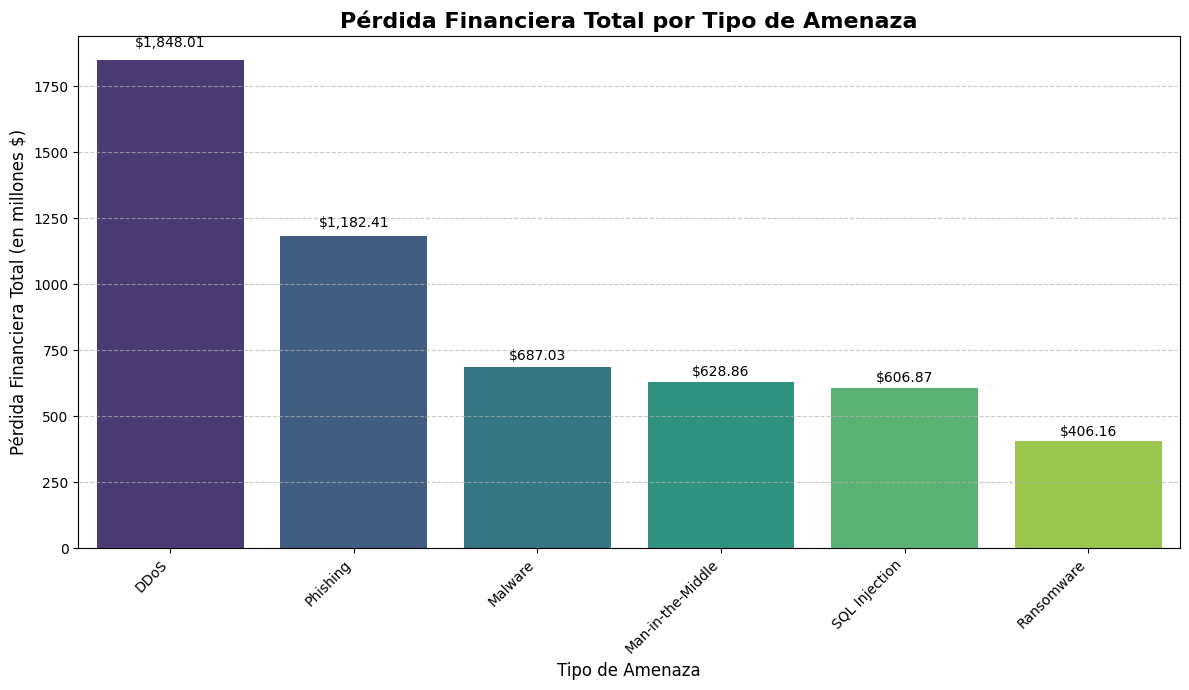

✅ Gráfico 1 generado: Pérdida Financiera Total por Tipo de Amenaza


In [36]:
# ============================================
# GRÁFICO 1: Pérdida Financiera Total por Tipo de Amenaza
# ============================================

plt.figure(figsize=(12, 7))

# Agrupar por tipo de amenaza y sumar el impacto económico
loss_by_attack_type = df_incidentes_clean.groupby('tipo_amenaza')['impacto_economico'].sum().sort_values(ascending=False)

# Crear gráfico de barras
sns.barplot(x=loss_by_attack_type.index, y=loss_by_attack_type.values, palette='viridis', hue=loss_by_attack_type.index, legend=False)

# Añadir títulos y etiquetas
plt.title('Pérdida Financiera Total por Tipo de Amenaza', fontsize=16, fontweight='bold')
plt.xlabel('Tipo de Amenaza', fontsize=12)
plt.ylabel('Pérdida Financiera Total (en millones $)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir valores en las barras
for index, value in enumerate(loss_by_attack_type.values):
    plt.text(index, value + (value * 0.02), f'${value:,.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("✅ Gráfico 1 generado: Pérdida Financiera Total por Tipo de Amenaza")

### Visualización 2: Número Total de Usuarios Afectados por Industria

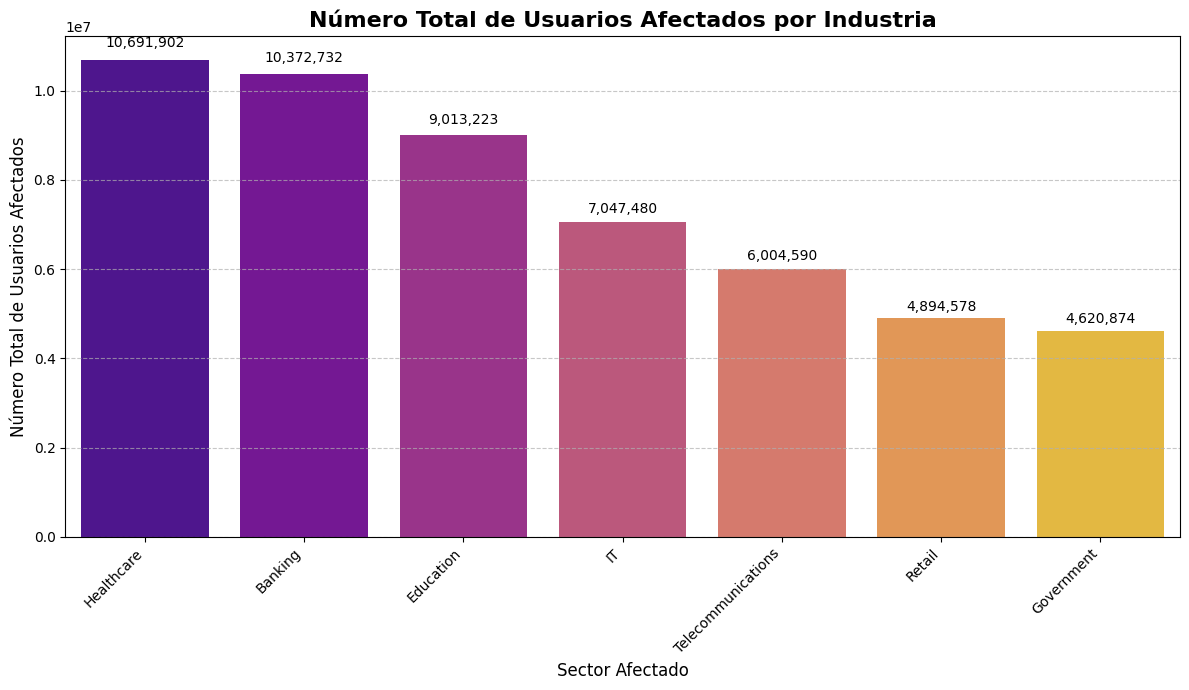

✅ Gráfico 2 generado: Número Total de Usuarios Afectados por Industria


In [37]:
# ============================================
# GRÁFICO 2: Número Total de Usuarios Afectados por Industria
# ============================================

plt.figure(figsize=(12, 7))

# Agrupar por sector afectado y sumar el número de usuarios afectados
users_by_industry = df_incidentes_clean.groupby('sector_afectado')['number_of_affected_users'].sum().sort_values(ascending=False)

# Crear gráfico de barras
sns.barplot(x=users_by_industry.index, y=users_by_industry.values, palette='plasma', hue=users_by_industry.index, legend=False)

# Añadir títulos y etiquetas
plt.title('Número Total de Usuarios Afectados por Industria', fontsize=16, fontweight='bold')
plt.xlabel('Sector Afectado', fontsize=12)
plt.ylabel('Número Total de Usuarios Afectados', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir valores en las barras
for index, value in enumerate(users_by_industry.values):
    plt.text(index, value + (value * 0.02), f'{value:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("✅ Gráfico 2 generado: Número Total de Usuarios Afectados por Industria")

### Visualización 3: Tendencia de Pérdida Financiera a lo Largo de los Años

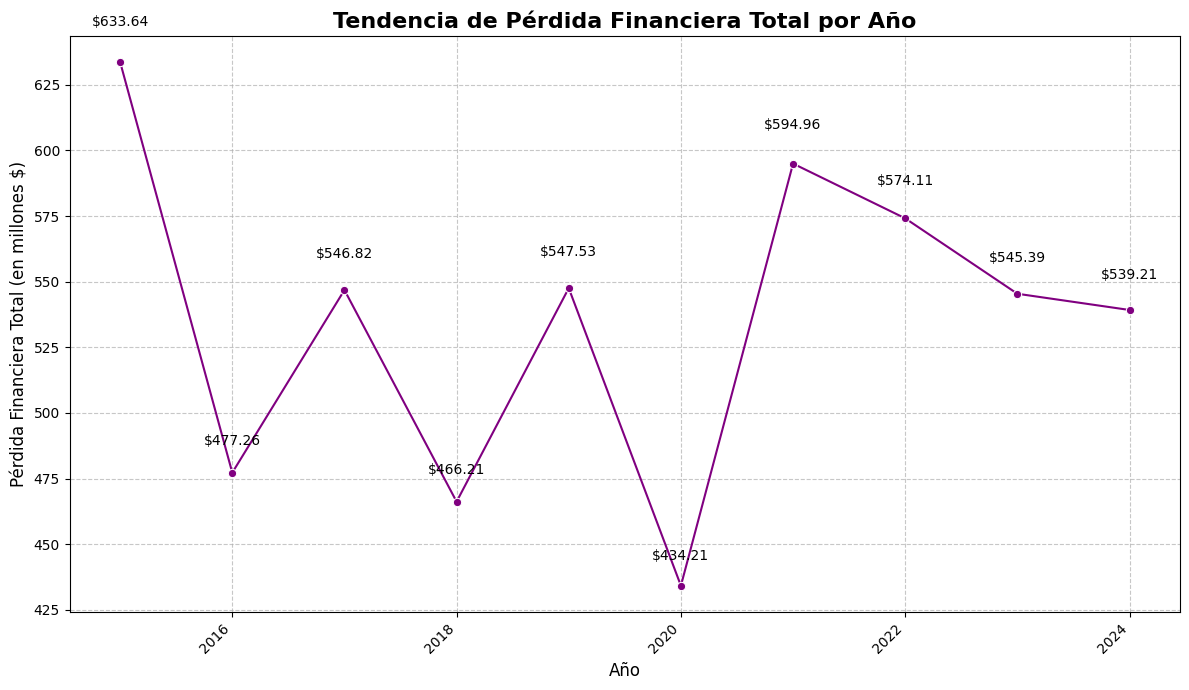

✅ Gráfico 3 generado: Tendencia de Pérdida Financiera a lo Largo de los Años


In [38]:
# ============================================
# GRÁFICO 3: Tendencia de Pérdida Financiera a lo Largo de los Años
# ============================================

plt.figure(figsize=(12, 7))

# Agrupar por año y sumar el impacto económico
loss_by_year = df_incidentes_clean.groupby('periodo_anual')['impacto_economico'].sum().reset_index()

# Crear gráfico de líneas
sns.lineplot(x='periodo_anual', y='impacto_economico', data=loss_by_year, marker='o', color='purple')

# Añadir títulos y etiquetas
plt.title('Tendencia de Pérdida Financiera Total por Año', fontsize=16, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Pérdida Financiera Total (en millones $)', fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')

# Añadir valores en los puntos de la línea
for x, y in zip(loss_by_year['periodo_anual'], loss_by_year['impacto_economico']):
    plt.text(x, y + (y * 0.02), f'${y:,.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("✅ Gráfico 3 generado: Tendencia de Pérdida Financiera a lo Largo de los Años")

## 📝 PASO 9: Resumen Final

Vamos a crear un resumen de todo lo que hicimos.

## Resumen final

En este análisis de ciberseguridad, hemos realizado una exploración exhaustiva de los datos de amenazas desde el 2015 hasta el 2024. Iniciamos cargando los datos desde una base de datos SQLite a DataFrames de Pandas, prestando especial atención a la estructura y calidad de los mismos. Posteriormente, se llevaron a cabo transformaciones clave, incluyendo el renombramiento de columnas para mayor claridad y el cálculo del impacto económico por tipo de amenaza. Hemos ejecutado varias consultas SQL para extraer información específica, como los tipos de amenaza, la defensa por firewall y la relación entre vulnerabilidad, defensa y pérdida financiera en la industria IT. Finalmente, se han generado visualizaciones significativas que muestran la pérdida financiera por tipo de amenaza, el número de usuarios afectados por industria y la tendencia de pérdida financiera a lo largo de los años. Este proceso nos ha permitido obtener una visión clara de las tendencias de ciberseguridad, los impactos financieros y las estrategias de defensa.

## 📚 PASO 10: Cerrar Conexión

Es importante cerrar la conexión a la base de datos cuando terminamos.

In [39]:
# ============================================
# CERRAR CONEXIÓN
# ============================================

# Cerrar conexión a la base de datos


print("✅ Conexión a la base de datos cerrada correctamente")

✅ Conexión a la base de datos cerrada correctamente


In [40]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.0/68.0 kB 5.3 MB/s eta 0:00:00


In [41]:
# Importar ProfileReport
from ydata_profiling import ProfileReport

# Generar el informe de perfil para df_amenazas
profile = ProfileReport(df_consolidado, title="Reporte de Perfil de Datos de las amenzas de ciberseguridad")

# Guardar el informe como un archivo HTML
profile.to_file("reporte_Datos de las amenzas de ciberseguridad.html")

print("✅ Reporte de perfil HTML generado: reporte_Datos de las amenzas de ciberseguridad.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 41.63it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Reporte de perfil HTML generado: reporte_Datos de las amenzas de ciberseguridad.html
